In [1]:
# Этот ноутбук подготовлен для ЛР3 (KWS).
# Запускайте ячейки сверху вниз.

# Лабораторная работа 3

**ФИО:** Алимбеков Рауль Азатович  
**Группа:** БВТ2201  
**Тема:** KWS (Keyword Spotting) для команд `yes/no/stop` на Google Speech Commands

В ноутбуке выполнены шаги ЛР3: подготовка данных, baseline, серия экспериментов, анализ ошибок и выбор финальной модели.

In [2]:
# Если библиотек не хватает, раскомментируйте строку ниже:
# !pip install -q numpy pandas matplotlib scikit-learn librosa soundfile torchaudio

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import joblib

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

TARGET_LABELS = ["yes", "no", "stop", "silence", "unknown"]

DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup completed")

Setup completed


## Шаг 1. Подготовка данных

Используется официальный датасет `torchaudio.datasets.SPEECHCOMMANDS` с учётом speaker-disjoint split (`training`, `validation`, `testing`) из ЛР2.

Используем все доступные записи целевых классов (без ограничения по количеству).

In [3]:
import librosa
import torchaudio

# Шаг 1: загрузка официальных split'ов
train_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="training", download=True)
val_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="validation", download=True)
test_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="testing", download=True)

print(f"train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
print("Dataset init OK")

train=84843, val=9981, test=11005
Dataset init OK


In [4]:
m = train_ds.get_metadata(0)
m

('speech_commands_v0.02/backward/0165e0e8_nohash_0.wav',
 16000,
 'backward',
 '0165e0e8',
 0)

In [5]:
# Шаг 1.1: распределение классов в сырых split (без фильтрации)

def count_labels_raw(dataset):
    counts = {}
    for rel_path in dataset._walker:
        label = Path(rel_path).parent.name
        counts[label] = counts.get(label, 0) + 1
    return pd.Series(counts).sort_values(ascending=False)

raw_train_counts = count_labels_raw(train_ds)
raw_val_counts = count_labels_raw(val_ds)
raw_test_counts = count_labels_raw(test_ds)

print(f"Raw train classes: {len(raw_train_counts)}")
print(f"Raw val classes: {len(raw_val_counts)}")
print(f"Raw test classes: {len(raw_test_counts)}")

print("\nAll classes in raw train:")
display(raw_train_counts.to_frame("count"))

print("\nAll classes in raw val:")
display(raw_val_counts.to_frame("count"))

print("\nAll classes in raw test:")
display(raw_test_counts.to_frame("count"))

# Общая сводная таблица по всем split
raw_counts_all = pd.concat(
    [
        raw_train_counts.rename("train"),
        raw_val_counts.rename("val"),
        raw_test_counts.rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nAll classes across train/val/test:")
display(raw_counts_all.sort_values("train", ascending=False))

Raw train classes: 35
Raw val classes: 35
Raw test classes: 35

All classes in raw train:


,count
zero,3250
five,3240
yes,3228
seven,3205
nine,3170
one,3140
down,3134
no,3130
two,3111
stop,3111



All classes in raw val:


,count
no,406
yes,397
seven,387
zero,384
six,378
down,377
four,373
off,373
go,372
five,367



All classes in raw test:


,count
five,445
up,425
two,424
yes,419
zero,418
left,412
stop,411
eight,408
nine,408
down,406



All classes across train/val/test:


,train,val,test
zero,3250,384,418
five,3240,367,445
yes,3228,397,419
seven,3205,387,406
nine,3170,356,408
one,3140,351,399
down,3134,377,406
no,3130,406,405
two,3111,345,424
stop,3111,350,411


In [6]:
# Шаг 2: функция выборки целевых классов из split

def collect_subset_paths(dataset, labels):
    rows = []
    counters = {lbl: 0 for lbl in labels}

    archive = Path(dataset._archive)

    for rel_path in dataset._walker:
        path_obj = Path(rel_path)
        label = path_obj.parent.name
        if label not in labels:
            continue

        # У некоторых версий torchaudio в _walker уже почти полный путь,
        # у других — относительный. Берем первый реально существующий вариант.
        candidates = [
            path_obj,
            archive / path_obj,
            Path.cwd() / path_obj,
        ]
        resolved = next((p for p in candidates if p.exists()), None)
        if resolved is None:
            continue

        rows.append((str(resolved), label))
        counters[label] += 1

    return rows, counters

base_labels = [lbl for lbl in TARGET_LABELS if lbl not in ("silence", "unknown")]

train_rows_base, train_count_base = collect_subset_paths(train_ds, base_labels)
val_rows_base, val_count_base = collect_subset_paths(val_ds, base_labels)
test_rows_base, test_count_base = collect_subset_paths(test_ds, base_labels)

print("Base labels collected:")
print("train:", train_count_base)
print("val:", val_count_base)
print("test:", test_count_base)
print("Example base file:", train_rows_base[0] if train_rows_base else "not found")

Base labels collected:
train: {'yes': 3228, 'no': 3130, 'stop': 3111}
val: {'yes': 397, 'no': 406, 'stop': 350}
test: {'yes': 419, 'no': 405, 'stop': 411}
Example base file: ('data/SpeechCommands/speech_commands_v0.02/no/012c8314_nohash_0.wav', 'no')


In [7]:
# Шаг 3.1: формируем класс unknown (стратифицированно по нецелевым словам)

def collect_unknown_paths(dataset, known_labels, unknown_count=None, seed=42):
    archive = Path(dataset._archive)
    rng = np.random.default_rng(seed)

    # Собираем неизвестные примеры по каждому классу отдельно
    per_label_rows = {}
    for rel_path in dataset._walker:
        path_obj = Path(rel_path)
        label = path_obj.parent.name

        # Исключаем целевые команды и служебные папки
        if label in known_labels or label == "_background_noise_":
            continue

        candidates = [path_obj, archive / path_obj, Path.cwd() / path_obj]
        resolved = next((p for p in candidates if p.exists()), None)
        if resolved is None:
            continue

        per_label_rows.setdefault(label, []).append((str(resolved), "unknown"))

    unknown_labels = sorted(per_label_rows.keys())
    if not unknown_labels:
        return [], 0

    # Если лимит не задан — берем все неизвестные записи
    if unknown_count is None:
        all_rows = []
        for lbl in unknown_labels:
            all_rows.extend(per_label_rows[lbl])
        return all_rows, len(unknown_labels)

    # Стратифицированная выборка: примерно поровну из каждого unknown-класса
    per_class = max(1, unknown_count // len(unknown_labels))
    remainder = unknown_count % len(unknown_labels)

    selected = []
    for i, lbl in enumerate(unknown_labels):
        pool = per_label_rows[lbl]
        take = per_class + (1 if i < remainder else 0)
        if len(pool) <= take:
            selected.extend(pool)
        else:
            idx = rng.choice(len(pool), size=take, replace=False)
            selected.extend([pool[j] for j in idx])

    # Если где-то классов было мало и не добрали общий лимит — добираем случайно из остатка
    if len(selected) < unknown_count:
        selected_set = set(selected)
        rest = []
        for lbl in unknown_labels:
            for row in per_label_rows[lbl]:
                if row not in selected_set:
                    rest.append(row)
        need = min(unknown_count - len(selected), len(rest))
        if need > 0:
            idx = rng.choice(len(rest), size=need, replace=False)
            selected.extend([rest[j] for j in idx])

    return selected, len(unknown_labels)

known_labels = ["yes", "no", "stop"]
train_unknown_count = max(train_count_base.values()) if train_count_base else 0
val_unknown_count = max(val_count_base.values()) if val_count_base else 0
test_unknown_count = max(test_count_base.values()) if test_count_base else 0

train_unknown, train_unknown_classes = collect_unknown_paths(train_ds, known_labels, train_unknown_count, seed=SEED + 10)
val_unknown, val_unknown_classes = collect_unknown_paths(val_ds, known_labels, val_unknown_count, seed=SEED + 11)
test_unknown, test_unknown_classes = collect_unknown_paths(test_ds, known_labels, test_unknown_count, seed=SEED + 12)

print("Unknown collected (stratified):")
print("train unknown:", len(train_unknown), "| unknown classes:", train_unknown_classes)
print("val unknown:", len(val_unknown), "| unknown classes:", val_unknown_classes)
print("test unknown:", len(test_unknown), "| unknown classes:", test_unknown_classes)
print("Approx per unknown class (train):", int(round(len(train_unknown) / max(train_unknown_classes, 1))))
print("Example unknown row:", train_unknown[0] if train_unknown else "not found")

Unknown collected (stratified):
train unknown: 3228 | unknown classes: 32
val unknown: 406 | unknown classes: 32
test unknown: 419 | unknown classes: 32
Approx per unknown class (train): 101
Example unknown row: ('data/SpeechCommands/speech_commands_v0.02/backward/bde0f20a_nohash_0.wav', 'unknown')


In [8]:
# Шаг 3: функция генерации класса silence

def make_silence_rows(dataset, count, seed=42):
    rng = np.random.default_rng(seed)

    archive = Path(dataset._archive)
    candidates = [
        archive / "_background_noise_",
        archive.parent / "speech_commands_v0.02" / "_background_noise_",
        DATA_DIR / "SpeechCommands" / "speech_commands_v0.02" / "_background_noise_",
    ]

    noise_files = []
    for c in candidates:
        files = sorted(c.glob("*.wav"))
        if files:
            noise_files = files
            break

    rows = []
    if noise_files:
        for _ in range(count):
            f = noise_files[rng.integers(0, len(noise_files))]
            y, sr = librosa.load(str(f), sr=None, mono=True)
            duration = len(y) / sr
            max_offset = max(0.0, duration - 1.0)
            offset = float(rng.uniform(0.0, max_offset)) if max_offset > 0 else 0.0
            rows.append((str(f), "silence", offset, 1.0))
    else:
        rows = [(None, "silence", 0.0, 1.0) for _ in range(count)]

    return rows

train_silence_count = max(train_count_base.values()) if train_count_base else 0
val_silence_count = max(val_count_base.values()) if val_count_base else 0
test_silence_count = max(test_count_base.values()) if test_count_base else 0

train_silence = make_silence_rows(train_ds, train_silence_count, seed=SEED)
val_silence = make_silence_rows(val_ds, val_silence_count, seed=SEED + 1)
test_silence = make_silence_rows(test_ds, test_silence_count, seed=SEED + 2)

print("Silence collected:")
print("train silence:", len(train_silence))
print("val silence:", len(val_silence))
print("test silence:", len(test_silence))
print("Example silence row:", train_silence[0] if train_silence else "not found")

Silence collected:
train silence: 3228
val silence: 406
test silence: 419
Example silence row: ('data/SpeechCommands/speech_commands_v0.02/_background_noise_/doing_the_dishes.wav', 'silence', 41.33494295097251, 1.0)


In [9]:
# Шаг 4: объединяем команды + silence + unknown
train_rows = train_rows_base + train_silence + train_unknown
val_rows = val_rows_base + val_silence + val_unknown
test_rows = test_rows_base + test_silence + test_unknown

train_count = dict(train_count_base)
val_count = dict(val_count_base)
test_count = dict(test_count_base)

train_count["silence"] = len(train_silence)
val_count["silence"] = len(val_silence)
test_count["silence"] = len(test_silence)

train_count["unknown"] = len(train_unknown)
val_count["unknown"] = len(val_unknown)
test_count["unknown"] = len(test_unknown)

print("Collected:")
print("train:", train_count)
print("val:", val_count)
print("test:", test_count)
print("Example final row:", train_rows[0] if train_rows else "not found")

Collected:
train: {'yes': 3228, 'no': 3130, 'stop': 3111, 'silence': 3228, 'unknown': 3228}
val: {'yes': 397, 'no': 406, 'stop': 350, 'silence': 406, 'unknown': 406}
test: {'yes': 419, 'no': 405, 'stop': 411, 'silence': 419, 'unknown': 419}
Example final row: ('data/SpeechCommands/speech_commands_v0.02/no/012c8314_nohash_0.wav', 'no')


In [10]:
# Feature engineering: MFCC + статистики по времени
from tqdm.auto import tqdm


def extract_features(audio, sr=16000, n_mfcc=20):
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    if len(audio) < sr:
        audio = np.pad(audio, (0, sr - len(audio)))
    elif len(audio) > sr:
        audio = audio[:sr]

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)

    # mean + std дают компактное представление для классических моделей
    feats = np.concatenate([
        mfcc.mean(axis=1),
        mfcc.std(axis=1),
        delta.mean(axis=1),
        delta.std(axis=1),
    ])
    return feats


def build_xy(rows, cache_prefix=None):
    if cache_prefix:
        x_path = ARTIFACTS_DIR / f"{cache_prefix}_X.npy"
        y_path = ARTIFACTS_DIR / f"{cache_prefix}_y.npy"
        if x_path.exists() and y_path.exists():
            print(f"Loaded cache: {cache_prefix}")
            X_cached = np.load(x_path)
            y_cached = np.load(y_path, allow_pickle=True)
            if len(y_cached) == len(rows):
                return X_cached, y_cached
            print(
                f"Cache size mismatch for {cache_prefix}: "
                f"cache={len(y_cached)} vs rows={len(rows)}. Recomputing..."
            )

    def normalize_audio_path(audio_path):
        if audio_path is None:
            return None

        p = Path(audio_path)
        if p.exists():
            return str(p)

        # Чиним старый путь вида data/SpeechCommands/data/SpeechCommands/...
        marker = "speech_commands_v0.02/"
        s = str(audio_path).replace("\\", "/")
        if marker in s:
            tail = s.split(marker, 1)[1]
            fixed = DATA_DIR / "SpeechCommands" / "speech_commands_v0.02" / tail
            if fixed.exists():
                return str(fixed)

        return str(p)

    X, y = [], []
    for row in tqdm(rows, desc=f"Extract {cache_prefix or 'dataset'}"):
        # Обычный класс: (audio_path, label)
        # Класс silence: (audio_path, "silence", offset_sec, duration_sec)
        if len(row) == 2:
            audio_path, label = row
            audio_path = normalize_audio_path(audio_path)
            if audio_path is None or not Path(audio_path).exists():
                continue
            audio, sr = librosa.load(audio_path, sr=None, mono=True)
        else:
            audio_path, label, offset_sec, duration_sec = row
            if audio_path is None:
                # Фолбек для класса silence: чистый нулевой сигнал 1 сек
                sr = 16000
                audio = np.zeros(sr, dtype=np.float32)
            else:
                audio_path = normalize_audio_path(audio_path)
                if audio_path is None or not Path(audio_path).exists():
                    continue
                audio, sr = librosa.load(
                    audio_path,
                    sr=None,
                    mono=True,
                    offset=offset_sec,
                    duration=duration_sec,
                )

        X.append(extract_features(audio, sr))
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    if cache_prefix:
        np.save(x_path, X)
        np.save(y_path, y)
        print(f"Saved cache: {cache_prefix}")

    return X, y


X_train, y_train = build_xy(train_rows, cache_prefix="train")
X_val, y_val = build_xy(val_rows, cache_prefix="val")
X_test, y_test = build_xy(test_rows, cache_prefix="test")

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Extract train: 100%|██████████| 15925/15925 [00:51<00:00, 311.49it/s]


Saved cache: train


Extract val: 100%|██████████| 1965/1965 [00:06<00:00, 295.80it/s]


Saved cache: val


Extract test: 100%|██████████| 2073/2073 [00:06<00:00, 302.55it/s]

Saved cache: test
Shapes: (15925, 80) (1965, 80) (2073, 80)


## Шаг 2. Baseline-модель

Baseline для классификации: `LogisticRegression` на MFCC-признаках.

Основная метрика: **macro F1** (согласовано с ЛР1/ЛР2).

In [11]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

baseline.fit(X_train, y_train)
val_pred_baseline = baseline.predict(X_val)

baseline_f1 = f1_score(y_val, val_pred_baseline, average="macro")
print(f"Baseline macro F1 (val): {baseline_f1:.4f}")
print(classification_report(y_val, val_pred_baseline, digits=4))

Baseline macro F1 (val): 0.7709
              precision    recall  f1-score   support

          no     0.6840    0.7463    0.7138       406
     silence     0.9760    1.0000    0.9878       406
        stop     0.7717    0.8400    0.8044       350
     unknown     0.5924    0.4581    0.5167       406
         yes     0.8175    0.8463    0.8317       397

    accuracy                         0.7761      1965
   macro avg     0.7683    0.7782    0.7709      1965
weighted avg     0.7680    0.7761    0.7696      1965



## Шаг 3-4. Экспериментальный пайплайн и серия экспериментов

Логируем эксперименты в таблицу `pandas`: модель, гиперпараметры, macro F1 на валидации.

Пробуем:
1. Улучшенную логистическую регрессию (поиск `C`)
2. RandomForest (поиск глубины/числа деревьев)

In [12]:
experiments = []

def log_experiment(name, model, X_tr, y_tr, X_va, y_va, params=None):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    score = f1_score(y_va, pred, average="macro")
    experiments.append({
        "name": name,
        "params": str(params) if params else "{}",
        "val_macro_f1": score,
    })
    return model, score, pred

# Exp 1: Logistic Regression + GridSearch
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1200, random_state=SEED)),
])

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid={"clf__C": [0.5, 1.0, 2.0, 5.0]},
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
)

lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_
_, lr_f1, lr_pred = log_experiment(
    "LogReg_tuned", lr_best, X_train, y_train, X_val, y_val, lr_grid.best_params_
)

# Exp 2: RandomForest + GridSearch
rf = RandomForestClassifier(random_state=SEED)
rf_grid = GridSearchCV(
    rf,
    param_grid={
        "n_estimators": [150, 250],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5],
    },
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
_, rf_f1, rf_pred = log_experiment(
    "RandomForest_tuned", rf_best, X_train, y_train, X_val, y_val, rf_grid.best_params_
)

exp_df = pd.DataFrame(experiments).sort_values("val_macro_f1", ascending=False)
exp_df

,name,params,val_macro_f1
0,LogReg_tuned,{'clf__C': 2.0},0.769147
1,RandomForest_tuned,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.759303


## Шаг 5. Анализ ошибок

Для лучшей модели строим confusion matrix и смотрим примеры ошибок.

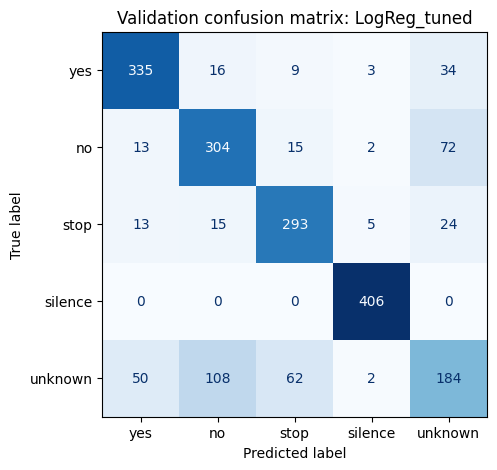

Количество ошибок на validation: 443


,true,pred
0,no,unknown
1,no,unknown
2,no,unknown
3,no,unknown
4,no,unknown
5,no,unknown
6,no,unknown
7,no,unknown
8,no,unknown
9,no,unknown


In [13]:
best_name = exp_df.iloc[0]["name"]
if best_name == "RandomForest_tuned":
    best_model = rf_best
else:
    best_model = lr_best

val_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val, val_pred_best, labels=TARGET_LABELS)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_LABELS)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Validation confusion matrix: {best_name}")
plt.show()

errors_idx = np.where(val_pred_best != y_val)[0]
print(f"Количество ошибок на validation: {len(errors_idx)}")

if len(errors_idx) > 0:
    sample_n = min(10, len(errors_idx))
    sample = errors_idx[:sample_n]
    err_df = pd.DataFrame({
        "true": y_val[sample],
        "pred": val_pred_best[sample],
    })
    display(err_df)
else:
    print("Ошибок на validation не найдено")

## Шаг 6. Финальная модель

Выбираем модель с лучшим `val_macro_f1`, переобучаем на `train + val`, оцениваем на `test` и сохраняем артефакт для инференса.

In [15]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_model.fit(X_trainval, y_trainval)
test_pred = best_model.predict(X_test)

test_f1 = f1_score(y_test, test_pred, average="macro")
print(f"Final model: {best_name}")
print(f"Macro F1 (test): {test_f1:.4f}")
print(classification_report(y_test, test_pred, digits=4))

model_path = ARTIFACTS_DIR / "kws_final_model.joblib"
joblib.dump({
    "model": best_model,
    "labels": TARGET_LABELS,
    "feature": "mfcc+delta(mean,std)",
    "sample_rate": 16000,
}, model_path)

print(f"Saved: {model_path}")

Final model: LogReg_tuned
Macro F1 (test): 0.7627
              precision    recall  f1-score   support

          no     0.6697    0.7309    0.6989       405
     silence     1.0000    1.0000    1.0000       419
        stop     0.8122    0.7786    0.7950       411
     unknown     0.5093    0.4582    0.4824       419
         yes     0.8163    0.8592    0.8372       419

    accuracy                         0.7656      2073
   macro avg     0.7615    0.7654    0.7627      2073
weighted avg     0.7619    0.7656    0.7630      2073

Saved: artifacts/kws_final_model.joblib


## Вывод

- Реализован baseline и улучшенные модели для KWS (`yes/no/stop`).
- Проведены эксперименты с логированием метрик.
- Выполнен анализ ошибок через confusion matrix и примеры misclassification.
- Выбрана финальная модель и сохранена в `artifacts/kws_final_model.joblib`.

### Компромиссы
- `LogReg`: быстрее и легче для edge/near-edge сценария.
- `RandomForest`: потенциально выше качество, но тяжелее по памяти и медленнее.

Для строгой оценки latency/размера модели можно дополнительно измерить время инференса и размер артефакта в отдельной ячейке.

## Дополнительный эксперимент: Log-Mel + CNN (PyTorch)

В этом эксперименте используем 2D log-mel спектрограммы и небольшую CNN.

Примечания:
- чтобы запустить быстрее, можно ограничить число примеров на класс (`CNN_MAX_PER_CLASS`);
- для финального сравнения можно снять ограничение (`None`) и увеличить число эпох.

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CNN_EPOCHS = 6
CNN_BATCH_SIZE = 64
CNN_LR = 1e-3
CNN_MAX_PER_CLASS = 1200  # None -> использовать все доступные записи в split

print("Device:", DEVICE)

Device: cpu


In [17]:
# Подготовка log-mel тензоров

def cap_rows_per_class(rows, max_per_class=None, seed=42):
    if max_per_class is None:
        return rows
    rng = np.random.default_rng(seed)
    by_label = {}
    for r in rows:
        lbl = r[1]
        by_label.setdefault(lbl, []).append(r)

    out = []
    for lbl, items in by_label.items():
        if len(items) <= max_per_class:
            out.extend(items)
        else:
            idx = rng.choice(len(items), size=max_per_class, replace=False)
            out.extend([items[i] for i in idx])
    return out


def row_to_audio(row):
    if len(row) == 2:
        audio_path, _ = row
        audio_path = Path(audio_path)
        y, sr = librosa.load(str(audio_path), sr=None, mono=True)
        return y, sr

    audio_path, _, offset_sec, duration_sec = row
    if audio_path is None:
        return np.zeros(16000, dtype=np.float32), 16000

    y, sr = librosa.load(str(audio_path), sr=None, mono=True, offset=offset_sec, duration=duration_sec)
    return y, sr


def extract_logmel(audio, sr=16000, n_mels=64, n_fft=512, hop_length=160):
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000

    if len(audio) < sr:
        audio = np.pad(audio, (0, sr - len(audio)))
    elif len(audio) > sr:
        audio = audio[:sr]

    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    # Нормализация на примере
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)
    return logmel.astype(np.float32)


class LogMelDataset(Dataset):
    def __init__(self, rows, label_to_idx):
        self.rows = rows
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        y, sr = row_to_audio(row)
        x = extract_logmel(y, sr)
        x = torch.from_numpy(x).unsqueeze(0)  # [1, n_mels, time]
        label = row[1]
        t = torch.tensor(self.label_to_idx[label], dtype=torch.long)
        return x, t


train_rows_cnn = cap_rows_per_class(train_rows, CNN_MAX_PER_CLASS, seed=SEED)
val_rows_cnn = cap_rows_per_class(val_rows, CNN_MAX_PER_CLASS, seed=SEED + 1)
test_rows_cnn = cap_rows_per_class(test_rows, CNN_MAX_PER_CLASS, seed=SEED + 2)

labels_cnn = sorted(list(set([r[1] for r in train_rows_cnn + val_rows_cnn + test_rows_cnn])))
label_to_idx = {l: i for i, l in enumerate(labels_cnn)}
idx_to_label = {i: l for l, i in label_to_idx.items()}

train_ds_cnn = LogMelDataset(train_rows_cnn, label_to_idx)
val_ds_cnn = LogMelDataset(val_rows_cnn, label_to_idx)
test_ds_cnn = LogMelDataset(test_rows_cnn, label_to_idx)

train_loader = DataLoader(train_ds_cnn, batch_size=CNN_BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds_cnn, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds_cnn, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0)

print("CNN labels:", labels_cnn)
print("Rows train/val/test:", len(train_rows_cnn), len(val_rows_cnn), len(test_rows_cnn))

CNN labels: ['no', 'silence', 'stop', 'unknown', 'yes']
Rows train/val/test: 6000 1965 2073


Epoch 01 | train_loss=1.1376 train_f1=0.5224 | val_loss=0.9981 val_f1=0.6027
Epoch 02 | train_loss=0.8971 train_f1=0.6468 | val_loss=0.8456 val_f1=0.6210
Epoch 03 | train_loss=0.7620 train_f1=0.7128 | val_loss=0.9058 val_f1=0.5407
Epoch 04 | train_loss=0.6692 train_f1=0.7467 | val_loss=1.0854 val_f1=0.4497
Epoch 05 | train_loss=0.6198 train_f1=0.7583 | val_loss=0.6243 val_f1=0.7568
Epoch 06 | train_loss=0.5769 train_f1=0.7780 | val_loss=0.9314 val_f1=0.5794

CNN classification report (val):
              precision    recall  f1-score   support

          no     0.6792    0.7980    0.7339       406
     silence     0.9830    0.9975    0.9902       406
        stop     0.6773    0.9114    0.7771       350
     unknown     0.5914    0.3744    0.4585       406
         yes     0.8822    0.7733    0.8242       397

    accuracy                         0.7669      1965
   macro avg     0.7626    0.7709    0.7568      1965
weighted avg     0.7645    0.7669    0.7559      1965

CNN macro F1 (t

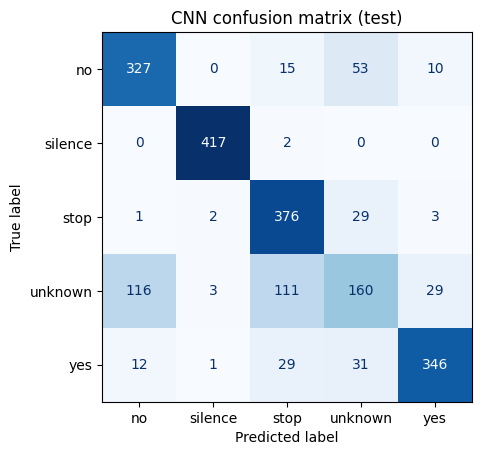

In [ ]:
class SmallKwsCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    all_true, all_pred = [], []
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = loss_fn(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        pred = torch.argmax(logits, dim=1)
        all_true.extend(yb.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(len(loader.dataset), 1)
    f1 = f1_score(all_true, all_pred, average="macro")
    return avg_loss, f1, all_true, all_pred


cnn_model = SmallKwsCNN(num_classes=len(labels_cnn)).to(DEVI.CE)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR)

best_state = None
best_val_f1 = -1.0

for epoch in range(1, CNN_EPOCHS + 1):
    tr_loss, tr_f1, _, _ = run_epoch(cnn_model, train_loader, optimizer)
    va_loss, va_f1, va_true, va_pred = run_epoch(cnn_model, val_loader, optimizer=None)

    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        best_state = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} train_f1={tr_f1:.4f} | "
        f"val_loss={va_loss:.4f} val_f1={va_f1:.4f}"
    )

if best_state is not None:
    cnn_model.load_state_dict(best_state)

# Валидируем лучшую модель
y_val_true_idx, y_val_pred_idx = run_epoch(cnn_model, val_loader, optimizer=None)[2:]
y_val_true_lbl = np.array([idx_to_label[i] for i in y_val_true_idx])
y_val_pred_lbl = np.array([idx_to_label[i] for i in y_val_pred_idx])

print("\nCNN classification report (val):")
print(classification_report(y_val_true_lbl, y_val_pred_lbl, labels=labels_cnn, digits=4))

# Тест
y_test_true_idx, y_test_pred_idx = run_epoch(cnn_model, test_loader, optimizer=None)[2:]
y_test_true_lbl = np.array([idx_to_label[i] for i in y_test_true_idx])
y_test_pred_lbl = np.array([idx_to_label[i] for i in y_test_pred_idx])

test_f1_cnn = f1_score(y_test_true_lbl, y_test_pred_lbl, average="macro")
print(f"CNN macro F1 (test): {test_f1_cnn:.4f}")
print(classification_report(y_test_true_lbl, y_test_pred_lbl, labels=labels_cnn, digits=4))

cm_cnn = confusion_matrix(y_test_true_lbl, y_test_pred_lbl, labels=labels_cnn)
ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=labels_cnn).plot(cmap="Blues", colorbar=False)
plt.title("CNN confusion matrix (test)")
plt.show()